### Adaptive RAG

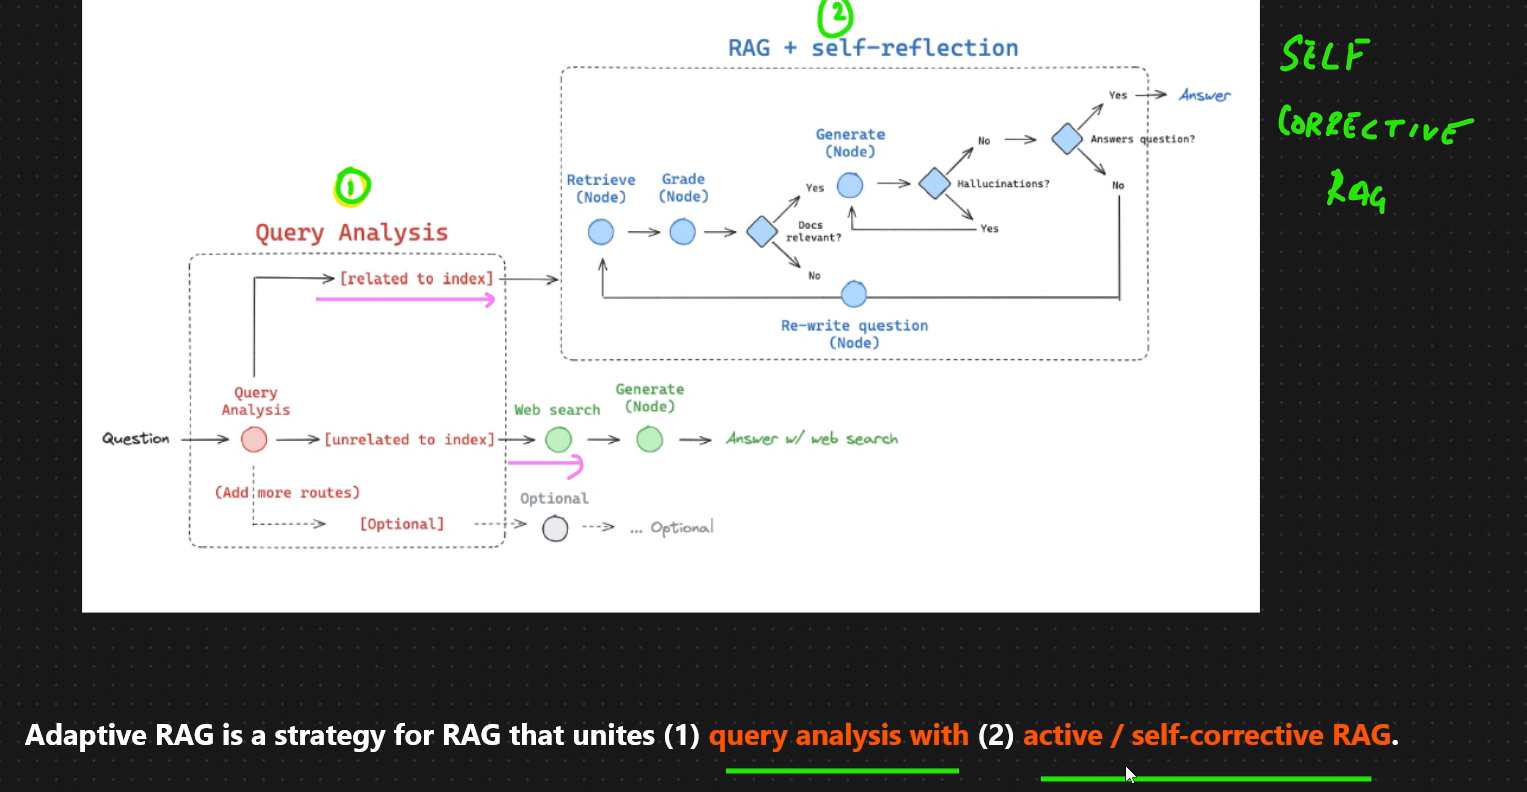

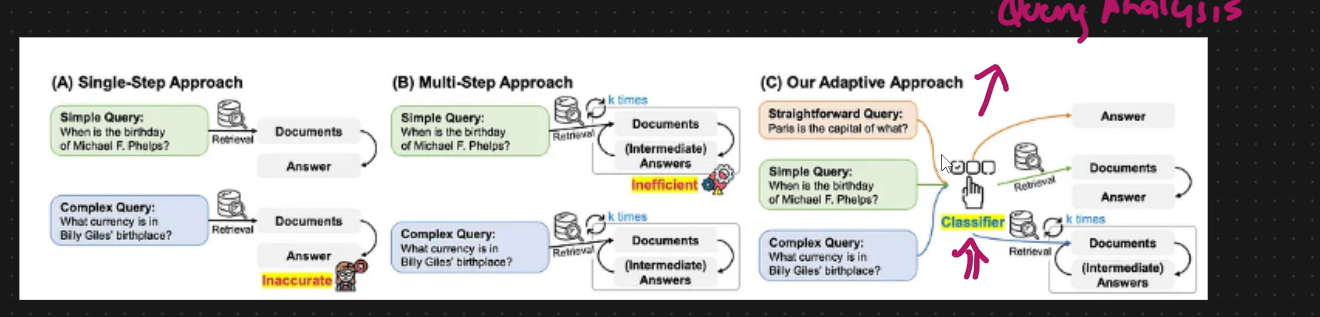

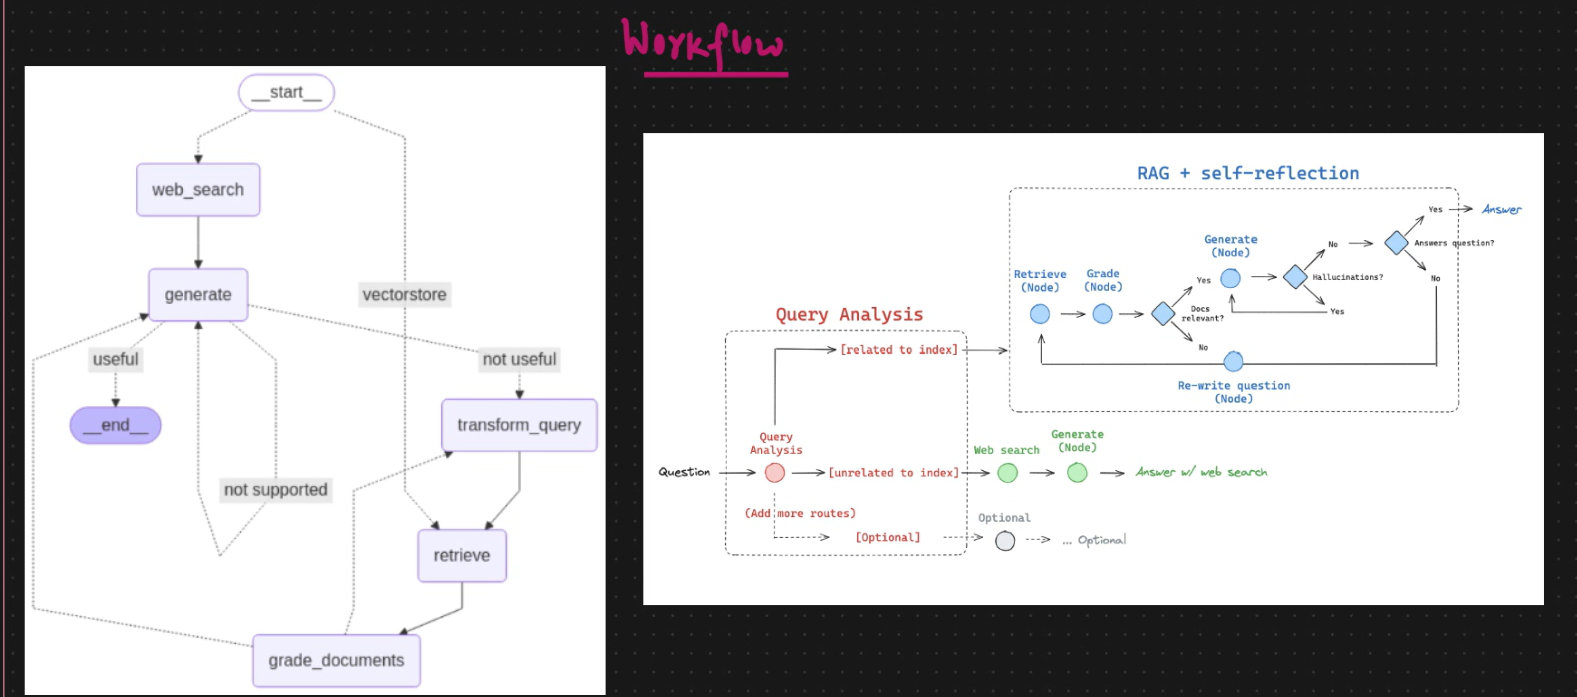

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()  # loading all the environment variables

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

In [2]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_ollama import OllamaEmbeddings

# Set embeddings
embd = OllamaEmbeddings(model="nomic-embed-text")

# Docs to index
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]

# Load
docs = [WebBaseLoader(url).load() for url in urls]
docs_list = [item for sublist in docs for item in sublist]
# Split
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=500,
    chunk_overlap=0,
)

doc_splits = text_splitter.split_documents(docs_list)

# Add to vectorstore
vectorstore = FAISS.from_documents(
    documents=doc_splits,
    embedding=embd,  # Uses the embeddings object created above
)

retriever = vectorstore.as_retriever()

C:\Users\tejas\AppData\Local\Temp\ipykernel_18752\2059192123.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WebBaseLoader
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [3]:
### Router

from typing import Literal

from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from langchain_groq import ChatGroq

# Data model
class RouteQuery(BaseModel):
    """Route a user query to the most relevant datasource."""

    datasource: Literal["vectorstore", "web_search"] = Field(
        ...,
        description="Given a user question choose to route it to web search or a vectorstore.",
    )


# LLM with structured output
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0,
)

structured_llm_router = llm.with_structured_output(RouteQuery)

# Prompt
system = """You are an expert at routing a user question to a vectorstore or web search.
The vectorstore contains documents related to agents, prompt engineering, and adversarial attacks.
Use the vectorstore for questions on these topics. Otherwise, use web-search."""

route_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "{question}"),
    ]
)

question_router = route_prompt | structured_llm_router

print(question_router.invoke({"question":"Who won the cricket world cup 2023 "}))

datasource='web_search'


In [4]:
print(question_router.invoke({"question":"What are the types of agent memory"}))

datasource='vectorstore'


In [6]:
### Retrieval Grader

# Data model
class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""

    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )


# LLM with structured output
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

structured_llm_grader = llm.with_structured_output(GradeDocuments)


# Prompt
system = """You are a grader assessing relevance of a retrieved document to a user question.
If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant.
It does not need to be a stringent test. The goal is to filter out erroneous retrievals.
Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."""

grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human",
            "Retrieved document:\n\n{document}\n\nUser question: {question}",
        ),
    ]
)

retrieval_grader = grade_prompt | structured_llm_grader

question = "agent memory"
docs = retriever.invoke(question)

doc_txt = docs[1].page_content

print(retrieval_grader.invoke({"question": question,"document": doc_txt,}))

binary_score='yes'


In [7]:
### Generate

from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_groq import ChatGroq

# Prompt
prompt = ChatPromptTemplate.from_template("""
Use the following context to answer the question.

Context:
{context}

Question:
{question}

Answer:
""")

# LLM
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

# Post-processing
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

# Chain
rag_chain = prompt | llm | StrOutputParser()

# Run
generation = rag_chain.invoke(
    {
        "context": format_docs(docs),
        "question": question,
    }
)

print(generation)

The agent's memory can be categorized into several types, similar to human memory. These include:

1. **Sensory Memory**: This is the earliest stage of memory, providing the ability to retain impressions of sensory information after the original stimuli have ended. Sensory memory typically only lasts for up to a few seconds.

2. **Short-Term Memory (STM) or Working Memory**: It stores information that the agent is currently aware of and needed to carry out complex cognitive tasks. Short-term memory is believed to have a limited capacity and lasts for a short period.

3. **Long-Term Memory (LTM)**: Long-term memory can store information for a remarkably long time, with an essentially unlimited storage capacity. There are two subtypes of LTM:
   - **Explicit / Declarative Memory**: This is memory of facts and events, and refers to those memories that can be consciously recalled.
   - **Implicit / Procedural Memory**: This type of memory is unconscious and involves skills and routines tha

In [8]:
### Hallucination Grader

# Data model
class GradeHallucinations(BaseModel):
    """Binary score for hallucination present in generation answer."""

    binary_score: str = Field(
        description="Answer is grounded in the facts, 'yes' or 'no'"
    )


# LLM with structured output
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

structured_llm_grader = llm.with_structured_output(
    GradeHallucinations
)


# Prompt
system = """You are a grader assessing whether an LLM generation is grounded in / supported by a set of retrieved facts.
Give a binary score 'yes' or 'no'. 'Yes' means that the answer is grounded in / supported by the set of facts."""

hallucination_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human","Set of facts:\n\n{documents}\n\nLLM generation: {generation}"),
    ]
)

hallucination_grader = (
    hallucination_prompt
    | structured_llm_grader
)

hallucination_grader.invoke(
    {
        "documents": docs,
        "generation": generation,
    }
)

GradeHallucinations(binary_score='yes')

In [9]:
### Answer Grader

# Data model
class GradeAnswer(BaseModel):
    """Binary score to assess answer addresses question."""

    binary_score: str = Field(
        description="Answer addresses the question, 'yes' or 'no'"
    )


# LLM with structured output
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

structured_llm_grader = llm.with_structured_output(
    GradeAnswer
)


# Prompt
system = """You are a grader assessing whether an answer addresses / resolves a question.
Give a binary score 'yes' or 'no'. 'Yes' means that the answer resolves the question."""

answer_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human",
            "User question:\n\n{question}\n\nLLM generation: {generation}",
        ),
    ]
)

answer_grader = answer_prompt | structured_llm_grader

answer_grader.invoke(
    {
        "question": question,
        "generation": generation,
    }
)

GradeAnswer(binary_score='yes')

In [10]:
### Question Re-writer

from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_groq import ChatGroq

# LLM
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

# Prompt
system = """You are a question re-writer that converts an input question to a better version that is optimized
for vectorstore retrieval. Look at the input and try to reason about the underlying semantic intent / meaning."""

re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human",
            "Here is the initial question:\n\n{question}\n\nFormulate an improved question.",
        ),
    ]
)

question_rewriter = re_write_prompt | llm | StrOutputParser()

question_rewriter.invoke(
    {
        "question": question,
    }
)

'Here\'s a rewritten version of the question:\n\n"What is agent memory in artificial intelligence, and how does it enable agents to store and retrieve information?"\n\nThis revised question provides more context and clarity, making it easier to retrieve relevant information from a vectorstore. It also specifies the domain (artificial intelligence) and provides a clear definition of what is being asked, which can help improve the accuracy of the search results. \n\nAlternatively, if you are looking for a more general or technical overview, the question could be rewritten as:\n\n* "Agent memory models and architectures"\n* "How do intelligent agents use memory to inform decision-making?"\n* "What are the key components and functions of agent memory in AI systems?" \n\nThese rephrased questions can help retrieve more specific and relevant information from a vectorstore, depending on the desired level of detail and context.'

In [11]:
### Search

from langchain_community.tools.tavily_search import TavilySearchResults

web_search_tool = TavilySearchResults(k=3)

C:\Users\tejas\AppData\Local\Temp\ipykernel_18752\730760015.py:5: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  web_search_tool = TavilySearchResults(k=3)


In [12]:
from typing import List
from typing_extensions import TypedDict


class GraphState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        question: question
        generation: LLM generation
        web_search: whether to add search
        documents: list of documents
    """

    question: str
    generation: str
    web_search: str
    documents: List[str]

In [13]:
from langchain_core.documents import Document

def retrieve(state):
    """
    Retrieve documents
    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, documents,
                      that contains retrieved documents
    """

    print("---RETRIEVE---")
    question = state["question"]
    # Retrieval
    documents = retriever.invoke(question)

    return {
        "documents": documents,
        "question": question,
    }

def generate(state):
    """
    Generate answer

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, generation,
                      that contains LLM generation
    """

    print("---GENERATE---")

    question = state["question"]
    documents = state["documents"]

    # RAG generation
    generation = rag_chain.invoke(
        {
            "context": documents,
            "question": question,
        }
    )

    return {
        "documents": documents,
        "question": question,
        "generation": generation,
    }

def grade_documents(state):
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with only filtered relevant documents
    """

    print("---CHECK DOCUMENT RELEVANCE TO QUESTION---")

    question = state["question"]
    documents = state["documents"]

    # Score each doc
    filtered_docs = []
    web_search = "No"

    for d in documents:
        score = retrieval_grader.invoke(
            {
                "question": question,
                "document": d.page_content,
            }
        )
        grade = score.binary_score

        if grade == "yes":
            print("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)

        else:
            print("---GRADE: DOCUMENT NOT RELEVANT---")
            web_search = "Yes"
            continue

    return {
        "documents": filtered_docs,
        "question": question,
        "web_search": web_search,
    }

def transform_query(state):
    """
    Transform the query to produce a better question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates question key with a re-phrased question
    """

    print("---TRANSFORM QUERY---")

    question = state["question"]
    documents = state["documents"]

    # Re-write question
    better_question = question_rewriter.invoke(
        {
            "question": question,
        }
    )

    return {
        "documents": documents,
        "question": better_question,
    }

def web_search(state):
    """
    Web search based on the re-phrased question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with appended web results
    """

    print("---WEB SEARCH---")

    question = state["question"]
    documents = state["documents"]

    # Web search
    docs = web_search_tool.invoke(
        {
            "query": question,
        }
    )

    web_results = "\n".join([d["content"] for d in docs])

    web_results = Document(
        page_content=web_results
    )

    documents.append(web_results)

    return {
        "documents": documents,
        "question": question,
    }

def decide_to_generate(state):
    """
    Determines whether to generate an answer, or re-generate a question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Binary decision for next node to call
    """

    print("---ASSESS GRADED DOCUMENTS---")

    question = state["question"]
    web_search = state["web_search"]
    documents = state["documents"]

    if web_search == "Yes":
        # All documents have been filtered check_relevance
        # We will re-generate a new query

        print(
            "---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---"
        )

        return "transform_query"

    else:
        # We have relevant documents, so generate answer

        print(
            "---DECISION: GENERATE---"
        )

        return "generate"

In [ ]:
## Craeete on your one taskkkkkkkkkk